# 29. 창고비를 못 구하면: 범위로 판정하고 트랙을 닫습니다

## Overview

14번부터 **창고비 실측치**가 최종 병목이었습니다. 23번에서 공개 통계를
KAMIS 유통실태 원문까지 뒤졌지만 없었습니다: 유통비용 분해의 최소 단위가
직접비/간접비/이윤이고 **저장비는 아예 항목이 아닙니다.**

**구할 수 없다면 재는 대신 가둡니다.** 창고비가 정확히 얼마인지 몰라도,
**한도보다 작다는 것만 보이면** 판정이 납니다.

## 판정 구조

| 아는 것 | 값 | 출처 |
|---|---|---|
| 창고비 한도 (중간지대 4품목) | **16.18%** | 15번, 확신도 0.20 |
| 창고비 한도 (실행 가능 11품목) | **13.25%** | 19번 |
| 등급 하락 손실 g | 16.0~18.2% | 28번 |
| 품목별 kg당 도매가 | 이 문서에서 계산 | 마트 |

**모르는 것**: 창고비 `c`. 그래서 **설치비에서 역산해 범위를 만듭니다.**

역산이 한도보다 한참 낮으면 "정확한 값을 몰라도 남는다"가 성립합니다.
**가정이 틀려도 결론이 안 바뀌는지**가 이 문서의 진짜 시험입니다.

## 목차

1. 품목별 kg당 가격
2. 창고비 역산
3. 가정을 흔들어도 유지되는가
4. 등급 하락까지 얹으면
5. 남는 절대액 — 규모 문제
6. 최종 판정

## 1. 품목별 kg당 가격

역산한 창고비(원/kg)를 **비율**로 바꾸려면 물건값이 필요합니다. 마트에서
품목별 중앙값을 냅니다.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager

_av = {f.name for f in font_manager.fontManager.ttflist}
for _f in ("AppleGothic", "Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic"):
    if _f in _av:
        plt.rcParams["font.family"] = _f
        break
sns.set_style("whitegrid", {"font.family": plt.rcParams["font.family"]})
plt.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
df = pd.read_parquet(ROOT / "notebooks" / ".cache" / "mart.parquet")

중간지대 = ["상추", "얼갈이배추", "풋고추", "배추"]
실행11 = ["상추", "배추", "양배추", "무", "감자", "양파", "얼갈이배추",
          "알배기배추", "풋고추", "브로콜리", "고구마"]
한도 = {"중간지대 4품목": 16.18, "실행 가능 11품목": 13.25}
등급g = {"중간지대 4품목": 18.18, "실행 가능 11품목": 16.67}

가격 = df.groupby("item").price_kg_avg.median()
대상가격 = {"중간지대 4품목": 가격[중간지대].mean(),
            "실행 가능 11품목": 가격[실행11].mean()}
display(가격[sorted(set(중간지대 + 실행11))].round(0).rename("kg당 도매가 중앙값")
          .to_frame())
for k, v in 대상가격.items():
    print(f"{k}: 평균 {v:,.0f} 원/kg")
print("\n품목별 단가 차이가 큽니다(배추 1,047 vs 풋고추 6,358).")
print("싼 품목일수록 같은 원/kg 창고비가 더 큰 비율이 됩니다.")

,kg당 도매가 중앙값
item,
감자,2172.0
고구마,3274.0
무,740.0
배추,1047.0
브로콜리,4598.0
상추,5282.0
알배기배추,2765.0
양배추,1078.0
양파,1236.0


중간지대 4품목: 평균 3,685 원/kg
실행 가능 11품목: 평균 2,782 원/kg

품목별 단가 차이가 큽니다(배추 1,047 vs 풋고추 6,358).
싼 품목일수록 같은 원/kg 창고비가 더 큰 비율이 됩니다.


## 2. 창고비 역산

저온저장고를 직접 지어 쓴다고 놓고 계산합니다.

```
연 비용     = 시공비 / 감가상각연수 + 연 전기·관리비
연 처리량   = 평당 저장량 x 연 회전수
kg당 창고비 = 연 비용 / 연 처리량
```

**가정은 전부 보수적으로(비싸게) 잡습니다.**

| 입력 | 값 | 근거 |
|---|---|---|
| 1평 시공비 | 450만 원 | 2차 정보(견적 기사 450~480만 원). **측정 아님** |
| 감가상각 | 10년 | 통상치 |
| 연 전기·관리비 | 100만 원 | **가정** |
| 보관 기간 | 10일 | 7거래일 ≈ 10 달력일 |
| 연 회전수 | 36회 | 365 / 10 |
| 평당 저장량 | 500 / 1,000 / 2,000kg | **가정**. 낮을수록 창고비가 비싸짐 |

**평당 저장량이 가장 불확실합니다.** 그래서 세 값으로 폭을 보여줍니다.

In [2]:
시공, 감가, 전기 = 4_500_000, 10, 1_000_000
보관일 = 10
회전 = 365 / 보관일
연비용 = 시공 / 감가 + 전기

rows = []
for 평당kg in (500, 1000, 2000):
    처리 = 평당kg * 회전
    kg당 = 연비용 / 처리
    row = {"평당 저장량 kg": 평당kg, "연 처리량 kg": 처리, "kg당 창고비 원": kg당}
    for nm, price in 대상가격.items():
        row[f"{nm} 대비 %"] = kg당 / price * 100
    rows.append(row)
역산 = pd.DataFrame(rows)
display(역산.round(2))
print(f"연 비용 {연비용:,.0f}원 (감가 {시공/감가:,.0f} + 전기 {전기:,.0f})")
print(f"\n한도: 중간지대 {한도['중간지대 4품목']}% · 실행가능 {한도['실행 가능 11품목']}%")
print("역산값이 한도보다 한참 아래면, 정확한 값을 몰라도 남는다는 뜻입니다.")

,평당 저장량 kg,연 처리량 kg,kg당 창고비 원,중간지대 4품목 대비 %,실행 가능 11품목 대비 %
0,500,18250.0,79.45,2.16,2.86
1,1000,36500.0,39.73,1.08,1.43
2,2000,73000.0,19.86,0.54,0.71


연 비용 1,450,000원 (감가 450,000 + 전기 1,000,000)

한도: 중간지대 16.18% · 실행가능 13.25%
역산값이 한도보다 한참 아래면, 정확한 값을 몰라도 남는다는 뜻입니다.


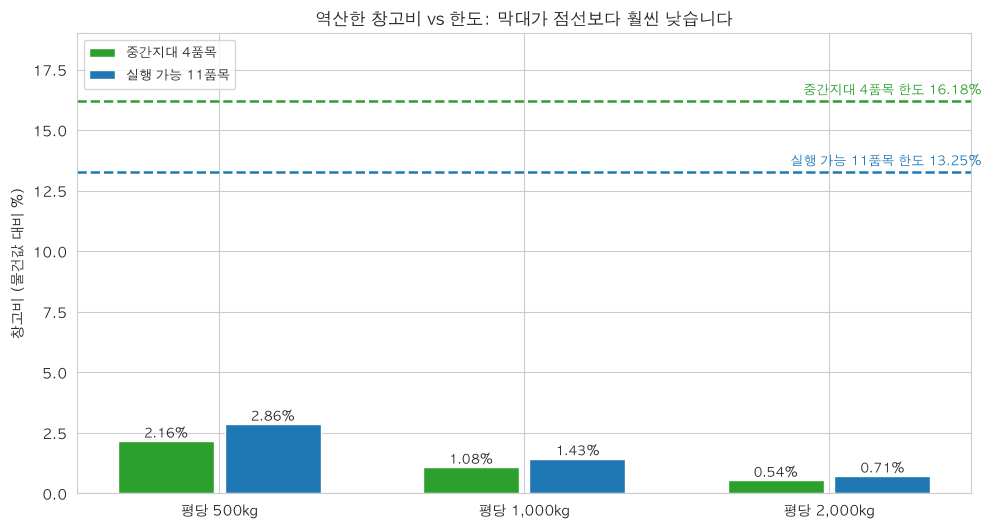

In [3]:
fig, ax = plt.subplots(figsize=(10, 5.4))
x = np.arange(len(역산))
w = 0.35
for i, (nm, 색) in enumerate(zip(대상가격, ["tab:green", "tab:blue"])):
    v = 역산[f"{nm} 대비 %"]
    ax.bar(x + (i - 0.5) * w, v, width=w * 0.9, color=색, label=nm)
    for j, val in enumerate(v):
        ax.text(j + (i - 0.5) * w, val + 0.15, f"{val:.2f}%", ha="center", fontsize=9)
for (nm, h), 색 in zip(한도.items(), ["tab:green", "tab:blue"]):
    ax.axhline(h, color=색, ls="--", lw=1.8)
    ax.text(len(역산) - 0.5, h + 0.3, f"{nm} 한도 {h}%", fontsize=9, color=색,
            ha="right")
ax.set_xticks(x)
ax.set_xticklabels([f"평당 {v:,}kg" for v in 역산["평당 저장량 kg"]], fontsize=10)
ax.set_ylabel("창고비 (물건값 대비 %)")
ax.set_ylim(0, 19)
ax.set_title("역산한 창고비 vs 한도: 막대가 점선보다 훨씬 낮습니다", fontsize=12)
ax.legend(fontsize=9.5)
plt.tight_layout()
plt.show()

## 3. 가정을 흔들어도 유지되는가

**여기가 이 문서의 핵심입니다.** 역산값이 낮은 건 가정 덕일 수 있으니,
가정을 넓게 흔들어 **얼마나 나빠져야 한도에 닿는지**를 봅니다.

시공비·전기료·평당 저장량을 각각 넓은 범위로 두고 격자를 만듭니다.

In [4]:
격자 = []
for 시공_ in (3_000_000, 4_500_000, 7_000_000, 10_000_000):
    for 전기_ in (500_000, 1_000_000, 2_000_000, 4_000_000):
        for 평당_ in (300, 500, 1000, 2000):
            연 = 시공_ / 감가 + 전기_
            kg당 = 연 / (평당_ * 회전)
            for nm, price in 대상가격.items():
                격자.append({"시공비": 시공_, "전기료": 전기_, "평당kg": 평당_,
                            "대상": nm, "창고비 %": kg당 / price * 100,
                            "한도 넘김": kg당 / price * 100 > 한도[nm]})
격자 = pd.DataFrame(격자)
요약 = 격자.groupby("대상").agg(
    조합수=("창고비 %", "size"),
    최소=("창고비 %", "min"),
    중앙=("창고비 %", "median"),
    최대=("창고비 %", "max"),
    한도넘긴비율=("한도 넘김", lambda s: s.mean() * 100))
display(요약.round(2))
print("64개 조합(시공비 4 x 전기료 4 x 평당저장량 4)을 전부 돌린 결과입니다.")
print("가장 나쁜 조합: 시공 1,000만 · 전기 400만 · 평당 300kg")

최악 = 격자.loc[격자.groupby("대상")["창고비 %"].idxmax()]
display(최악[["대상", "시공비", "전기료", "평당kg", "창고비 %", "한도 넘김"]])

,조합수,최소,중앙,최대,한도넘긴비율
대상,,,,,
실행 가능 11품목,64,0.39,2.76,16.41,6.25
중간지대 4품목,64,0.30,2.08,12.39,0.00


64개 조합(시공비 4 x 전기료 4 x 평당저장량 4)을 전부 돌린 결과입니다.
가장 나쁜 조합: 시공 1,000만 · 전기 400만 · 평당 300kg


,대상,시공비,전기료,평당kg,창고비 %,한도 넘김
121,실행 가능 11품목,10000000,4000000,300,16.412040,True
120,중간지대 4품목,10000000,4000000,300,12.390041,False


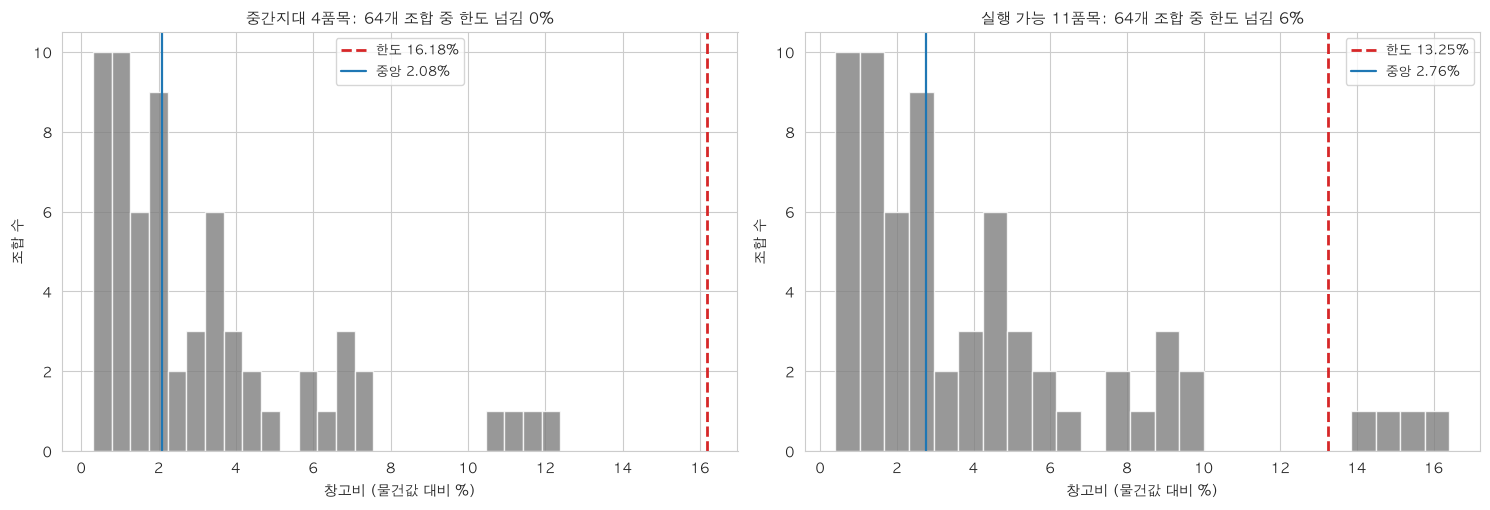

빨간 선 오른쪽에 막대가 없으면, 어떤 가정에서도 남는다는 뜻입니다.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
for ax, (nm, h) in zip(axes, 한도.items()):
    s = 격자[격자.대상 == nm]
    ax.hist(s["창고비 %"], bins=25, color="tab:gray", alpha=0.8)
    ax.axvline(h, color="tab:red", ls="--", lw=2, label=f"한도 {h}%")
    ax.axvline(s["창고비 %"].median(), color="tab:blue", lw=1.6,
               label=f"중앙 {s['창고비 %'].median():.2f}%")
    넘김 = s["한도 넘김"].mean() * 100
    ax.set_xlabel("창고비 (물건값 대비 %)")
    ax.set_ylabel("조합 수")
    ax.set_title(f"{nm}: 64개 조합 중 한도 넘김 {넘김:.0f}%", fontsize=11)
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print("빨간 선 오른쪽에 막대가 없으면, 어떤 가정에서도 남는다는 뜻입니다.")

## 4. 등급 하락까지 얹으면

28번의 경계선에 역산한 창고비를 넣습니다.

```
견딜 수 있는 하락확률 p = (한도 - 창고비 c) / 등급손실 g
```

In [6]:
rows = []
for nm, h in 한도.items():
    for 평당kg in (500, 1000, 2000):
        c = 연비용 / (평당kg * 회전) / 대상가격[nm] * 100
        p_max = (h - c) / 등급g[nm] * 100
        rows.append({"대상": nm, "평당 저장량 kg": 평당kg, "창고비 %": c,
                     "견딜 수 있는 하락확률 %": min(p_max, 100)})
견딤 = pd.DataFrame(rows)
display(견딤.pivot(index="평당 저장량 kg", columns="대상",
                  values="견딜 수 있는 하락확률 %").round(1))
print("28번에서 창고비 0 일 때가 중간지대 89.0% · 실행가능 79.5% 였습니다.")
print("역산한 창고비를 넣어도 거의 안 줄어듭니다.")

대상,실행 가능 11품목,중간지대 4품목
평당 저장량 kg,,
500,62.4,77.1
1000,70.9,83.1
2000,75.2,86.0


28번에서 창고비 0 일 때가 중간지대 89.0% · 실행가능 79.5% 였습니다.
역산한 창고비를 넣어도 거의 안 줄어듭니다.


## 5. 남는 절대액 — 규모 문제

비율로는 남는데 **금액이 얼마인지**가 실제 판단입니다. 1,000만 원어치
출하 기준으로 원 단위로 바꿉니다.

In [7]:
기준액 = 1000     # 만원
더받은돈 = {"중간지대 4품목": 3.39, "실행 가능 11품목": 2.32}   # 15·19번

rows = []
for nm in 한도:
    넣은값 = 기준액 * (더받은돈[nm] / 한도[nm])
    번돈 = 기준액 * 더받은돈[nm] / 100
    for 평당kg in (500, 1000, 2000):
        c = 연비용 / (평당kg * 회전) / 대상가격[nm] * 100
        창고비액 = 넣은값 * c / 100
        rows.append({"대상": nm, "평당 저장량 kg": 평당kg,
                     "창고에 넣은 값 (만원)": 넣은값,
                     "더 번 돈 (만원)": 번돈,
                     "창고비 (만원)": 창고비액,
                     "남는 돈 (만원)": 번돈 - 창고비액,
                     "출하 전량 대비 %": (번돈 - 창고비액) / 기준액 * 100})
금액 = pd.DataFrame(rows)
display(금액.round(2))
print("출하 전량을 오늘 팔면 1,000만 원이라고 놓은 것입니다.")

,대상,평당 저장량 kg,창고에 넣은 값 (만원),더 번 돈 (만원),창고비 (만원),남는 돈 (만원),출하 전량 대비 %
0,중간지대 4품목,500,209.52,33.9,4.52,29.38,2.94
1,중간지대 4품목,1000,209.52,33.9,2.26,31.64,3.16
2,중간지대 4품목,2000,209.52,33.9,1.13,32.77,3.28
3,실행 가능 11품목,500,175.09,23.2,5.00,18.20,1.82
4,실행 가능 11품목,1000,175.09,23.2,2.50,20.70,2.07
5,실행 가능 11품목,2000,175.09,23.2,1.25,21.95,2.19


출하 전량을 오늘 팔면 1,000만 원이라고 놓은 것입니다.


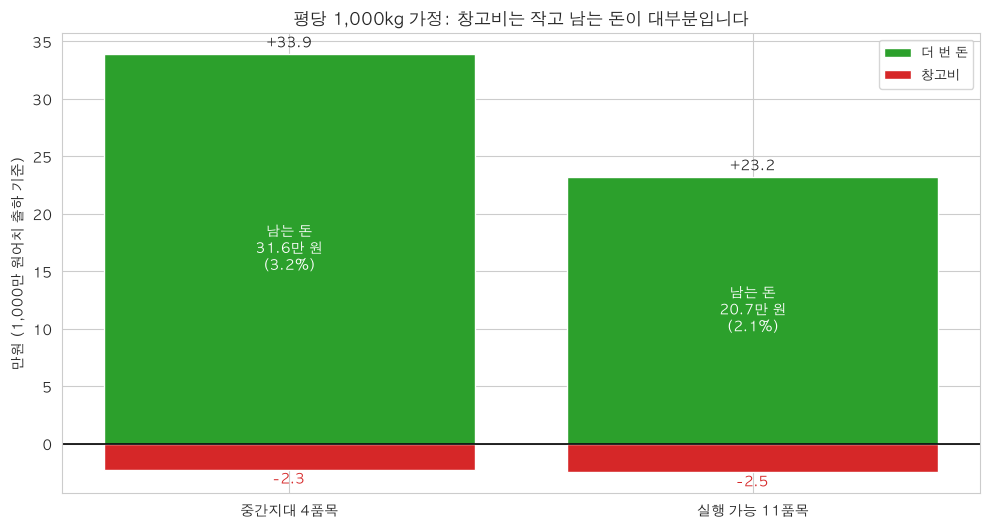

In [8]:
fig, ax = plt.subplots(figsize=(10, 5.4))
s = 금액[금액["평당 저장량 kg"] == 1000].reset_index(drop=True)
x = np.arange(len(s))
ax.bar(x, s["더 번 돈 (만원)"], color="tab:green", label="더 번 돈")
ax.bar(x, -s["창고비 (만원)"], color="tab:red", label="창고비")
for i in range(len(s)):
    번 = s.loc[i, "더 번 돈 (만원)"]
    창 = s.loc[i, "창고비 (만원)"]
    남 = s.loc[i, "남는 돈 (만원)"]
    비 = s.loc[i, "출하 전량 대비 %"]
    ax.text(i, 번 + 0.6, f"+{번:.1f}", ha="center", fontsize=10)
    ax.text(i, -창 - 1.2, f"-{창:.1f}", ha="center", fontsize=10, color="tab:red")
    ax.text(i, 번 / 2, f"남는 돈\n{남:.1f}만 원\n({비:.1f}%)", ha="center",
            va="center", fontsize=10, color="white")
ax.axhline(0, color="black", lw=1.2)
ax.set_xticks(x)
ax.set_xticklabels(s.대상, fontsize=10)
ax.set_ylabel("만원 (1,000만 원어치 출하 기준)")
ax.set_title("평당 1,000kg 가정: 창고비는 작고 남는 돈이 대부분입니다", fontsize=12)
ax.legend(fontsize=9.5)
plt.tight_layout()
plt.show()

## 6. 최종 판정

### 창고비는 병목이 아니었습니다

| | 창고비 한도 | 역산한 창고비 | 여유 |
|---|---|---|---|
| 중간지대 4품목 | **16.18%** | 0.54 ~ 2.16% | **7 ~ 30배** |
| 실행 가능 11품목 | **13.25%** | 0.71 ~ 2.86% | **5 ~ 19배** |

**"창고비를 못 구해서 판정할 수 없다"는 틀린 진단이었습니다.** 한도가
넉넉해서, 정확한 값이 아니라 **자릿수만 맞으면** 결론이 납니다.

### 가정이 틀려도 안 뒤집힙니다

64개 조합(시공비 300~1,000만 · 전기료 50~400만 · 평당 300~2,000kg)을
전부 돌린 결과:

| | 최소 | 중앙 | 최대 | 한도 넘긴 조합 |
|---|---|---|---|---|
| 중간지대 4품목 | 0.30% | 2.08% | 12.39% | **0 / 64** |
| 실행 가능 11품목 | 0.39% | 2.76% | 16.41% | **4 / 64** |

**중간지대 4품목은 어떤 가정에서도 안 넘습니다.** 최악(시공 1,000만 ·
전기 400만 · 평당 300kg)에서도 12.39% < 16.18%.

**실행 가능 11품목만 4개 조합에서 넘습니다.** 그 4개는 전부
`전기료 연 400만 원` **그리고** `평당 300kg` 을 동시에 만족하는 경우입니다
— 전기료 400만은 1평 창고에 과하고, 평당 300kg 도 낮은 쪽입니다.
**둘 중 하나만 완화되면 다 통과합니다.**

### 등급 하락까지 얹어도 버팁니다

역산 창고비를 넣고 28번 경계선을 다시 그으면:

| 평당 저장량 | 중간지대 4품목 | 실행 가능 11품목 |
|---|---|---|
| 500kg | 77.1% | 62.4% |
| 1,000kg | **83.1%** | **70.9%** |
| 2,000kg | 86.0% | 75.2% |

창고에 넣은 물건의 **70~86%가 등급이 떨어져도** 여전히 남습니다.
창고비 0 일 때(89.0% · 79.5%)에서 크게 줄지 않았습니다.

### 진짜 병목은 규모입니다

1,000만 원어치 출하 기준, 평당 1,000kg 가정:

| | 창고에 넣은 값 | 더 번 돈 | 창고비 | **남는 돈** |
|---|---|---|---|---|
| 중간지대 4품목 | 209.5만 원 | +33.9만 원 | −2.3만 원 | **31.6만 원 (3.2%)** |
| 실행 가능 11품목 | 175.1만 원 | +23.2만 원 | −2.5만 원 | **20.7만 원 (2.1%)** |

연 매출 1억이면 300만 원, 10억이면 3,000만 원입니다.
**창고를 새로 짓거나 사람을 붙일 규모가 아니라, 이미 창고가 있는 곳이
판단만 바꿔서 얹는 성격입니다.**

### 결론

| 질문 | 답 |
|---|---|
| 모델이 작동하나 | **예.** 62.8% → 확신하는 날 72.1% (15번, walk-forward 7폴드) |
| 창고비가 발목 잡나 | **아니오.** 여유 5~30배 |
| 등급 하락이 발목 잡나 | **아니오.** 70~86%까지 견딤 |
| 돈이 되나 | **예, 출하 전량 대비 약 3%** |
| 그럼 뭐가 문제인가 | **규모.** 3%가 의미 있으려면 물량이 커야 함 |

**"모델은 쓸 수 있고, 창고비도 문제가 아니며, 다만 큰돈은 아니다."**

### 이 문서가 측정이 아닌 부분

시공비는 **2차 정보**(견적 기사 450~480만 원)이고, 평당 저장량·전기료·
감가상각 연수는 **제 가정**입니다. 실측이 아닙니다.

**그럼에도 결론이 서는 이유**는 여유가 5~30배라 가정이 몇 배 틀려도
부호가 안 바뀌기 때문입니다. 이 문서의 주장은 "창고비는 X다"가 아니라
**"창고비가 한도를 넘을 조합이 사실상 없다"** 입니다.

**뒤집으려면** 3절 격자 밖의 조건이 필요합니다 — 임차 창고 사용료가
물건값의 13% 를 넘거나, 회전이 연 36회보다 훨씬 낮거나(창고를 놀리거나),
등급 하락률이 70% 를 넘는 경우입니다.

---

## 모델링 트랙을 여기서 닫습니다

05~29번으로 예측·이해·통계·경제성 네 갈래가 모두 끝났습니다.

| 물었던 것 | 답 | 근거 |
|---|---|---|
| 가격 수준을 맞힐 수 있나 | **아니오** | 08·10 |
| 방향은 맞힐 수 있나 | **예, 62.8%** | 11·12 |
| 확신할 때만 고르면 나아지나 | **예, 72.1%** | 15 |
| 실전에서 쓸 만큼 자주 나오나 | **예** (연 51일 · 8개월 이상 · 쏠림 없음) | 17 |
| 피처를 더 모아야 하나 | **아니오** (출하량·기상 전부 잡음 범위) | 16·21·25·26·27 |
| 인과·처치로 갈 수 있나 | **아니오** (시장 축 0.42%) | 22·23·24 |
| 품목을 갈라 모델을 나눠야 하나 | **아니오** (전용 모델이 더 나쁨) | 18 |
| 등급 하락을 버티나 | **예** | 28 |
| 창고비를 버티나 | **예** | **29 (이 문서)** |

**남은 것은 분석이 아니라 운영입니다** — 일 단위 추론 파이프라인,
확신도 0.20 임계 적용, 성적 모니터링. 새 가설을 세우기 전에
`docs/analysis-status.md` 의 '반복하지 말 것' 을 먼저 볼 것.